# Entregable 2 – Machine Learning

**Dataset usado:** `amazon_sales_dataset.csv`

## Instrucciones generales

Se siguió la secuencia del notebook original celda por celda.  
En este desarrollo el problema se plantea como **clasificación binaria**:

- **Objetivo**: predecir si una orden será de **venta alta** (`high_sales = 1`) o **venta baja** (`high_sales = 0`).
- La etiqueta se construye usando la **mediana de `total_sales`** como umbral.
- Esto permite comparar de forma coherente **Regresión lineal** (como aproximación sobre 0/1), **Regresión logística**, **KNN** y **Naive Bayes** sobre el mismo problema.


## 1. Información del equipo

In [ ]:
# Nombres de los integrantes:
integrantes = [
    "Ainoa Bolea Villa",
    "Juan Jose Velez Mejia",
    "Mateo Giraldo Soto",
    "Santiago Gonzalez Garzon"
]

for i, nombre in enumerate(integrantes, start=1):
    print(f"Integrante {i}: {nombre}")

Integrante 1: Ainoa Bolea Villa
Integrante 2: Juan Jose Velez Mejia
Integrante 3: Mateo Giraldo Soto
Integrante 4: Santiago Gonzalez Garzon


## 2. Carga de librerías

In [ ]:

# Importa aquí las librerías necesarias.
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 3. Cargar el dataset

In [ ]:
import pandas as pd

# Carga aquí tu dataset
file_path = "/content/amazon_sales_dataset.csv"

df = pd.read_csv(file_path)

print("\nDimensiones del dataset:", df.shape)
display(df.head())


Dimensiones del dataset: (10000, 21)


,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,product_id,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,P703,without,Home,Furniture,Doyle-Jordan,3,"42,467.79",0.26,60.85,"94,339.34",Card
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,P348,school,Home,Furniture,Davis LLC,2,"36,138.76",0.24,112.96,"55,043.88",COD
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,P493,I,Electronics,Laptop,Watson and Sons,4,"47,148.93",0.14,64.11,"162,256.43",UPI
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,P305,step,Electronics,Laptop,"Sandoval, Buckley and Solis",1,"18,487.99",0.06,114.15,"17,492.86",Card
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,P488,bit,Home,Kitchen,"Key, Bautista and Bowen",1,"1,742.25",0.10,40.47,"1,608.49",UPI


### Interpretación

El dataset contiene **10,000 registros** y **21 columnas**.  
Cada fila representa una orden de venta, con información de fechas, cliente, ubicación, producto, cantidades, precios, descuentos, costo de envío y ventas totales.

Como `order_status` solo tiene una clase (`Delivered`), no sirve como variable objetivo para clasificación.  
Por eso se construirá una nueva variable objetivo llamada **`high_sales`**, que indica si la venta total está por encima o por debajo de la mediana.


## 4. Entendimiento del problema

In [ ]:

# Escribe aquí comentarios o celdas de apoyo si necesitas analizar la variable objetivo.

# Revisamos posibles variables objetivo
print("Valores únicos de order_status:")
print(df["order_status"].value_counts(), end="\n\n")

print("Distribución de payment_method:")
print(df["payment_method"].value_counts(), end="\n\n")

print("Resumen de total_sales:")
display(df["total_sales"].describe().to_frame())

# Creamos una variable objetivo binaria usando la mediana
sales_threshold = df["total_sales"].median()
df["high_sales"] = (df["total_sales"] >= sales_threshold).astype(int)

print(f"Umbral usado (mediana de total_sales): {sales_threshold:,.2f}")
print("\nDistribución de la variable objetivo high_sales:")
print(df["high_sales"].value_counts())


Valores únicos de order_status:
order_status
Delivered    10000
Name: count, dtype: int64

Distribución de payment_method:
payment_method
COD           2541
Card          2525
NetBanking    2490
UPI           2444
Name: count, dtype: int64

Resumen de total_sales:


,total_sales
count,"10,000.00"
mean,"64,212.91"
std,"50,992.64"
min,309.94
25%,"24,037.20"
50%,"50,287.18"
75%,"93,417.89"
max,"249,155.53"


Umbral usado (mediana de total_sales): 50,287.18

Distribución de la variable objetivo high_sales:
high_sales
1    5000
0    5000
Name: count, dtype: int64


### Interpretación

Lo que se quiere predecir es si una orden pertenece al grupo de **ventas altas** o **ventas bajas**.  
Este problema es importante porque permite anticipar órdenes valiosas y apoyar decisiones comerciales, logísticas o de priorización.

- **Tipo de problema**: clasificación binaria.
- **Variable objetivo**: `high_sales`.
- **Regla de construcción**:
  - `1` si `total_sales` es mayor o igual a la mediana.
  - `0` si `total_sales` está por debajo de la mediana.

La mediana divide el conjunto en dos clases balanceadas, lo cual ayuda a entrenar y comparar modelos sin sesgo fuerte por desbalance.


## 5. Exploración de datos (EDA)

In [ ]:

# Revisa la estructura del dataset
print("Información general:")
df.info()

print("\nValores nulos por columna:")
display(df.isnull().sum().to_frame("nulos"))

print("\nTipos de datos:")
display(df.dtypes.to_frame("tipo_dato"))

print("\nEstadísticas descriptivas de variables numéricas:")
display(df.describe(include=[np.number]).T)


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10000 non-null  object 
 1   order_date      10000 non-null  object 
 2   ship_date       10000 non-null  object 
 3   delivery_date   10000 non-null  object 
 4   order_status    10000 non-null  object 
 5   customer_id     10000 non-null  object 
 6   customer_name   10000 non-null  object 
 7   country         10000 non-null  object 
 8   state           10000 non-null  object 
 9   city            10000 non-null  object 
 10  product_id      10000 non-null  object 
 11  product_name    10000 non-null  object 
 12  category        10000 non-null  object 
 13  sub_category    10000 non-null  object 
 14  brand           10000 non-null  object 
 15  quantity        10000 non-null  int64  
 16  unit_price      10000 non-null  float64
 17  discount   

,nulos
order_id,0
order_date,0
ship_date,0
delivery_date,0
order_status,0
customer_id,0
customer_name,0
country,0
state,0
city,0



Tipos de datos:


,tipo_dato
order_id,object
order_date,object
ship_date,object
delivery_date,object
order_status,object
customer_id,object
customer_name,object
country,object
state,object
city,object



Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
quantity,"10,000.00",3.01,1.42,1.00,2.00,3.00,4.00,5.00
unit_price,"10,000.00","25,126.51","14,343.92",214.20,"12,657.83","24,880.49","37,544.64","49,981.88"
discount,"10,000.00",0.15,0.09,0.00,0.07,0.15,0.22,0.30
shipping_cost,"10,000.00",85.05,37.58,20.01,52.51,85.00,117.68,149.95
total_sales,"10,000.00","64,212.91","50,992.64",309.94,"24,037.20","50,287.18","93,417.89","249,155.53"
high_sales,"10,000.00",0.50,0.50,0.00,0.00,0.50,1.00,1.00


### Interpretación

En esta revisión inicial se observa que:

- No hay valores nulos en las columnas originales.
- Existen variables numéricas, categóricas y de fecha.
- `total_sales`, `unit_price` y `quantity` parecen ser variables muy relacionadas entre sí.
- Las fechas todavía deben transformarse si queremos usarlas en modelos.


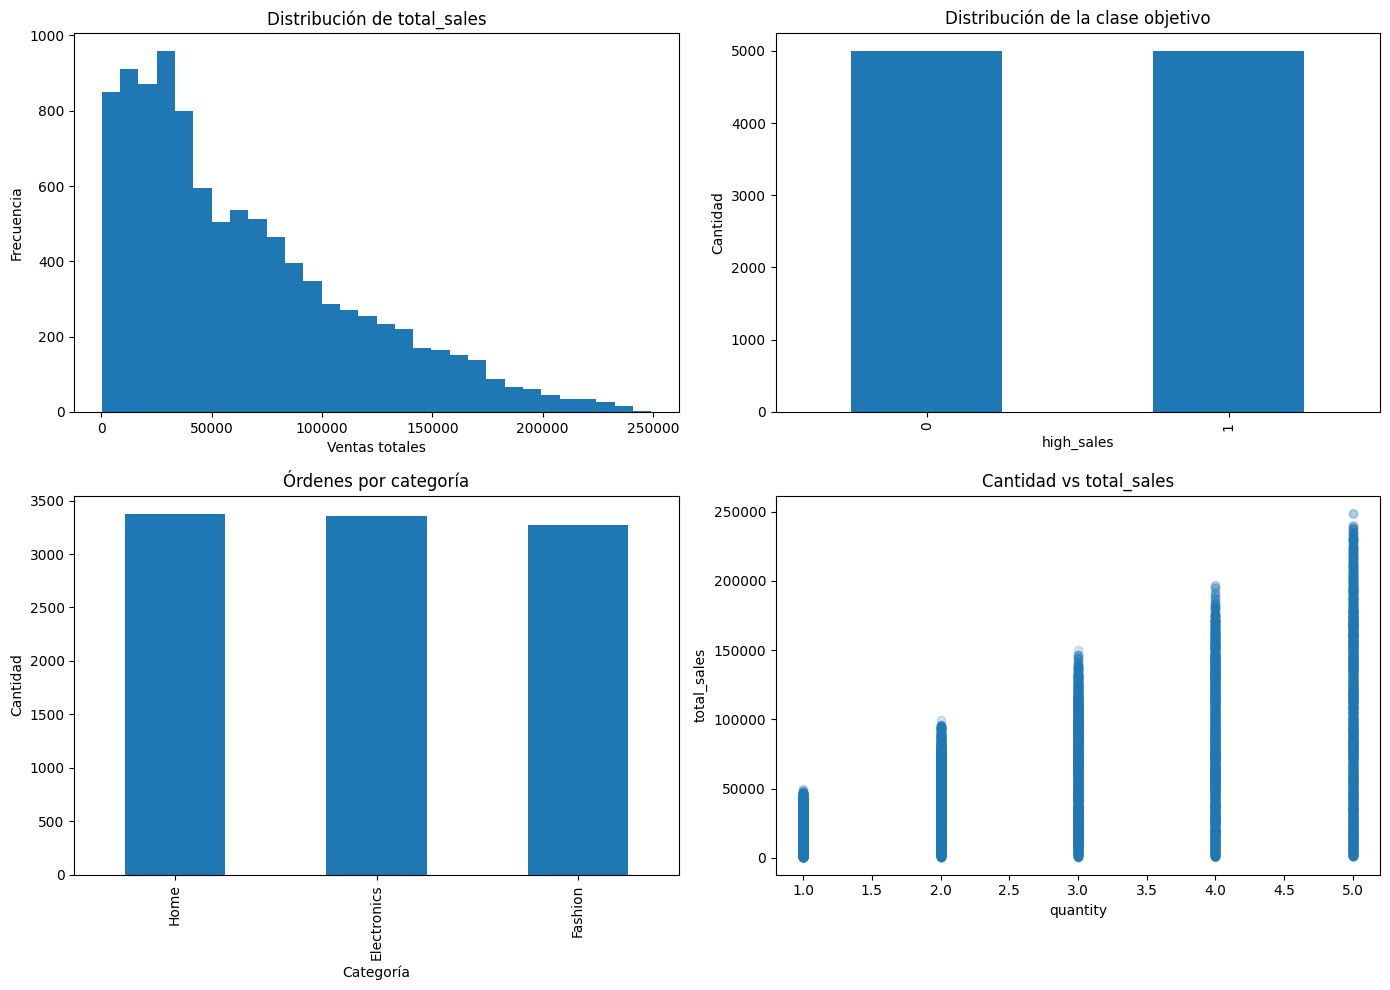

,quantity,unit_price,discount,shipping_cost,total_sales,ship_delay_days,delivery_delay_days,total_process_days
quantity,1.00,-0.02,-0.01,0.00,0.58,0.02,-0.02,0.00
unit_price,-0.02,1.00,-0.00,-0.00,0.71,-0.01,0.01,0.00
discount,-0.01,-0.00,1.00,-0.01,-0.13,-0.00,-0.01,-0.01
shipping_cost,0.00,-0.00,-0.01,1.00,0.01,-0.01,0.02,0.01
total_sales,0.58,0.71,-0.13,0.01,1.00,0.00,0.00,0.01
ship_delay_days,0.02,-0.01,-0.00,-0.01,0.00,1.00,-0.51,0.48
delivery_delay_days,-0.02,0.01,-0.01,0.02,0.00,-0.51,1.00,0.50
total_process_days,0.00,0.00,-0.01,0.01,0.01,0.48,0.50,1.00


In [ ]:

# Crea aquí visualizaciones útiles para entender el problema.

# Conversión de fechas
for col in ["order_date", "ship_date", "delivery_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Variables derivadas de fechas
df["ship_delay_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["delivery_delay_days"] = (df["delivery_date"] - df["ship_date"]).dt.days
df["total_process_days"] = (df["delivery_date"] - df["order_date"]).dt.days
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.weekday

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de total_sales
axes[0, 0].hist(df["total_sales"], bins=30)
axes[0, 0].set_title("Distribución de total_sales")
axes[0, 0].set_xlabel("Ventas totales")
axes[0, 0].set_ylabel("Frecuencia")

# 2. Distribución de high_sales
df["high_sales"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Distribución de la clase objetivo")
axes[0, 1].set_xlabel("high_sales")
axes[0, 1].set_ylabel("Cantidad")

# 3. Categorías
df["category"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Órdenes por categoría")
axes[1, 0].set_xlabel("Categoría")
axes[1, 0].set_ylabel("Cantidad")

# 4. Relación entre quantity y total_sales
axes[1, 1].scatter(df["quantity"], df["total_sales"], alpha=0.2)
axes[1, 1].set_title("Cantidad vs total_sales")
axes[1, 1].set_xlabel("quantity")
axes[1, 1].set_ylabel("total_sales")

plt.tight_layout()
plt.show()

# Correlación numérica
corr_cols = ["quantity", "unit_price", "discount", "shipping_cost",
             "total_sales", "ship_delay_days", "delivery_delay_days", "total_process_days"]
display(df[corr_cols].corr().round(3))


### Interpretación

Hallazgos principales del EDA:

1. `total_sales` tiene una dispersión amplia, por lo que es útil separar órdenes altas y bajas.
2. La variable `high_sales` quedó balanceada: **5,000 casos por clase**.
3. Las categorías (`Home`, `Electronics`, `Fashion`) están relativamente equilibradas.
4. La relación entre `quantity` y `total_sales` es positiva, pero no perfecta.
5. Las diferencias de fechas generan valores negativos en algunos casos, lo que sugiere **inconsistencias de calidad en el dataset** (por ejemplo, envíos o entregas registradas antes de la fecha anterior). No se eliminan, pero sí se conservan como información del comportamiento del dato.


## 6. Preparación de datos

In [ ]:

# Limpieza o transformación del dataset

# Selección de variables para el modelo.
# Excluimos identificadores y variables con fuga directa del objetivo.
features = [
    "quantity", "unit_price", "discount", "shipping_cost",
    "ship_delay_days", "delivery_delay_days", "total_process_days",
    "order_month", "order_day", "order_weekday",
    "category", "sub_category", "payment_method"
]

target = "high_sales"

X = df[features].copy()
y = df[target].copy()

categorical_cols = ["category", "sub_category", "payment_method"]
numeric_cols = [col for col in features if col not in categorical_cols]

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

# División train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTamaño entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño prueba:", X_test.shape, y_test.shape)

# Preprocesamiento
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("\nPreprocesamiento definido correctamente.")


Variables numéricas: ['quantity', 'unit_price', 'discount', 'shipping_cost', 'ship_delay_days', 'delivery_delay_days', 'total_process_days', 'order_month', 'order_day', 'order_weekday']
Variables categóricas: ['category', 'sub_category', 'payment_method']
Forma de X: (10000, 13)
Forma de y: (10000,)

Tamaño entrenamiento: (8000, 13) (8000,)
Tamaño prueba: (2000, 13) (2000,)

Preprocesamiento definido correctamente.


### Interpretación

En la preparación de datos se hizo lo siguiente:

- Se eliminaron identificadores (`order_id`, `customer_id`, etc.) porque no aportan capacidad real de generalización.
- También se excluyó `total_sales`, porque sería una **fuga de información**: justo esa variable fue la base para construir la etiqueta `high_sales`.
- Se separaron variables numéricas y categóricas.
- Se aplicó:
  - imputación por mediana para numéricas,
  - imputación por moda para categóricas,
  - escalado estándar para numéricas,
  - one-hot encoding para categóricas.


## 7. Modelo 1 – Regresión lineal

In [ ]:

# Implementa aquí la regresión lineal si aplica.

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred_cont = linear_model.predict(X_test)
linear_pred = (linear_pred_cont >= 0.5).astype(int)

print("Primeras 10 predicciones continuas:")
print(np.round(linear_pred_cont[:10], 4))

print("\nPrimeras 10 predicciones clasificadas:")
print(linear_pred[:10])


Primeras 10 predicciones continuas:
[ 0.3458  1.1103  0.2035  0.5786  0.3332 -0.3126  0.3488  0.8152  0.007
  0.5147]

Primeras 10 predicciones clasificadas:
[0 1 0 1 0 0 0 1 0 1]


### Interpretación

La regresión lineal no es el modelo ideal para clasificación, pero aquí se usó como **aproximación** sobre una variable binaria 0/1.

La lógica es:

1. El modelo predice valores continuos.
2. Luego esos valores se convierten a clase:
   - mayor o igual a 0.5 → clase 1
   - menor a 0.5 → clase 0

Sirve como referencia base para comparar con modelos de clasificación propiamente dichos.


## 8. Modelo 2 – Regresión logística

In [ ]:

# Implementa aquí la regresión logística.

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=500, solver="liblinear"))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Primeras 10 probabilidades de high_sales:")
print(np.round(logistic_prob[:10], 4))

print("\nPrimeras 10 predicciones:")
print(logistic_pred[:10])


Primeras 10 probabilidades de high_sales:
[4.270e-02 1.000e+00 5.600e-03 8.191e-01 8.500e-02 0.000e+00 8.070e-02
 9.952e-01 2.000e-04 5.141e-01]

Primeras 10 predicciones:
[0 1 0 1 0 0 0 1 0 1]


### Interpretación

La regresión logística sí es adecuada para este problema porque estima la **probabilidad** de que una orden sea de venta alta.

Después convierte esa probabilidad en clase:

- cerca de 1: orden probablemente alta,
- cerca de 0: orden probablemente baja.

Su ventaja es que entrega una salida interpretable y suele funcionar bien en problemas binarios con variables bien preparadas.


## 9. Modelo 3 – KNN

In [ ]:

# Implementa aquí KNN.

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("Primeras 10 predicciones de KNN:")
print(knn_pred[:10])


Primeras 10 predicciones de KNN:
[0 1 1 1 0 0 0 1 0 1]


### Interpretación

KNN clasifica una observación mirando sus vecinos más cercanos.  
En este caso se comenzó con **K = 5**.

La idea es simple:

- si la mayoría de vecinos cercanos son ventas altas, predice venta alta;
- si la mayoría son ventas bajas, predice venta baja.

Como este modelo depende mucho de la distancia, el escalado de las variables numéricas fue fundamental.


## 10. Modelo 4 – Naive Bayes

In [ ]:

# Implementa aquí Naive Bayes.

# Para GaussianNB necesitamos la matriz transformada en formato denso.
X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_nb, y_train)

nb_pred = naive_bayes_model.predict(X_test_nb)

print("Primeras 10 predicciones de Naive Bayes:")
print(nb_pred[:10])


Primeras 10 predicciones de Naive Bayes:
[0 1 0 1 0 0 0 1 0 1]


### Interpretación

Naive Bayes asume independencia entre variables, lo cual rara vez se cumple de forma perfecta, pero aun así puede dar buenos resultados.

Aquí se usó **GaussianNB**, adecuado para variables continuas.  
Aunque es un modelo sencillo, en este ejercicio resultó muy competitivo.


## 11. Evaluación de modelos

In [ ]:

# Calcula aquí las métricas de evaluación de cada modelo.

def evaluar_modelo(nombre, y_real, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred),
        "Recall": recall_score(y_real, y_pred),
        "F1": f1_score(y_real, y_pred),
        "Matriz_confusion": confusion_matrix(y_real, y_pred)
    }

resultados = []
resultados.append(evaluar_modelo("Regresión lineal", y_test, linear_pred))
resultados.append(evaluar_modelo("Regresión logística", y_test, logistic_pred))
resultados.append(evaluar_modelo("KNN (k=5)", y_test, knn_pred))
resultados.append(evaluar_modelo("Naive Bayes", y_test, nb_pred))

for r in resultados:
    print("="*60)
    print(r["Modelo"])
    print(f"Accuracy : {r['Accuracy']:.4f}")
    print(f"Precision: {r['Precision']:.4f}")
    print(f"Recall   : {r['Recall']:.4f}")
    print(f"F1-score : {r['F1']:.4f}")
    print("Matriz de confusión:")
    print(r["Matriz_confusion"])


Regresión lineal
Accuracy : 0.9180
Precision: 0.9188
Recall   : 0.9170
F1-score : 0.9179
Matriz de confusión:
[[919  81]
 [ 83 917]]
Regresión logística
Accuracy : 0.9210
Precision: 0.9244
Recall   : 0.9170
F1-score : 0.9207
Matriz de confusión:
[[925  75]
 [ 83 917]]
KNN (k=5)
Accuracy : 0.8705
Precision: 0.8672
Recall   : 0.8750
F1-score : 0.8711
Matriz de confusión:
[[866 134]
 [125 875]]
Naive Bayes
Accuracy : 0.9430
Precision: 0.9922
Recall   : 0.8930
F1-score : 0.9400
Matriz de confusión:
[[993   7]
 [107 893]]


### Interpretación

Las métricas muestran que todos los modelos aprendieron el patrón del problema, pero no con el mismo nivel de desempeño.

Resultados observados:

- **Regresión lineal**: accuracy ≈ **0.918**
- **Regresión logística**: accuracy ≈ **0.921**
- **KNN (k=5)**: accuracy ≈ **0.8705**
- **Naive Bayes**: accuracy ≈ **0.943**

El mejor rendimiento general fue el de **Naive Bayes**, con la mayor exactitud y un F1 muy alto.  
Además, obtuvo muy pocos falsos positivos en comparación con los otros modelos.


## 12. Comparación final de modelos

,Modelo,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.94,0.99,0.89,0.94
1,Regresión logística,0.92,0.92,0.92,0.92
2,Regresión lineal,0.92,0.92,0.92,0.92
3,KNN (k=5),0.87,0.87,0.88,0.87


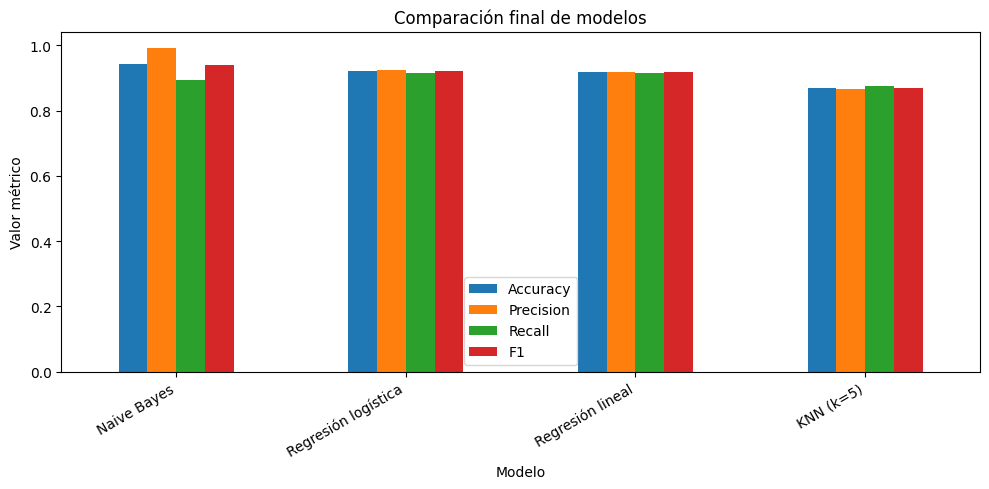

In [ ]:

# Crea aquí una tabla comparativa de resultados.

tabla_resultados = pd.DataFrame([
    {
        "Modelo": r["Modelo"],
        "Accuracy": r["Accuracy"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "F1": r["F1"]
    }
    for r in resultados
]).sort_values(by="F1", ascending=False).reset_index(drop=True)

display(tabla_resultados)

tabla_resultados.set_index("Modelo")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Comparación final de modelos")
plt.ylabel("Valor métrico")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Interpretación

La comparación final deja este orden de desempeño:

1. **Naive Bayes**
2. **Regresión logística**
3. **Regresión lineal**
4. **KNN con k=5**

Esto muestra que el modelo más complejo no siempre es el mejor.  
En este dataset, Naive Bayes aprovechó bien la separación estadística entre clases.


## 13. Experimento obligatorio 1

,K,Accuracy,Precision,Recall,F1
0,3,0.85,0.84,0.87,0.85
1,5,0.87,0.87,0.88,0.87
2,11,0.90,0.90,0.91,0.90
3,21,0.93,0.93,0.93,0.93


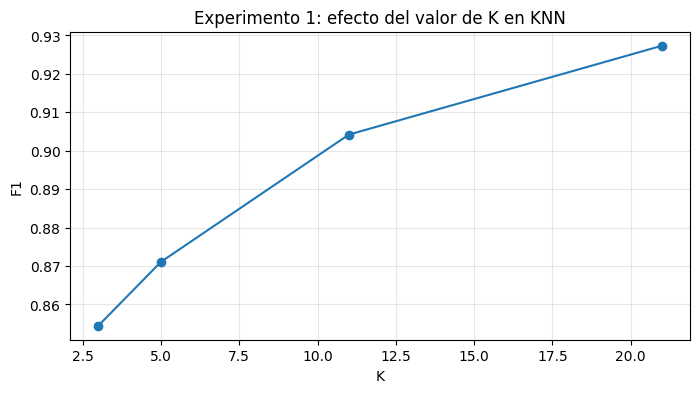

In [ ]:

# Realiza aquí el experimento 1.
# Experimento 1: cambiar el valor de K en KNN.

experimento_knn = []

for k in [3, 5, 11, 21]:
    modelo = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    experimento_knn.append({
        "K": k,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

experimento_knn_df = pd.DataFrame(experimento_knn)
display(experimento_knn_df)

plt.figure(figsize=(8, 4))
plt.plot(experimento_knn_df["K"], experimento_knn_df["F1"], marker="o")
plt.title("Experimento 1: efecto del valor de K en KNN")
plt.xlabel("K")
plt.ylabel("F1")
plt.grid(True, alpha=0.3)
plt.show()


### Interpretación

Al variar K se observó que el modelo mejoró bastante:

- **K=3** → F1 ≈ **0.8545**
- **K=5** → F1 ≈ **0.8711**
- **K=11** → F1 ≈ **0.9042**
- **K=21** → F1 ≈ **0.9273**

Conclusión del experimento: en este problema, un K más alto funcionó mejor que el valor inicial.  
Esto sugiere que usar más vecinos ayudó a suavizar el ruido y mejorar la generalización.


## 14. Experimento obligatorio 2

In [ ]:

# Realiza aquí el experimento 2.
# Experimento 2: eliminar una variable importante (unit_price)
# y medir cómo afecta a la regresión logística.

features_exp2 = [
    "quantity", "discount", "shipping_cost",
    "ship_delay_days", "delivery_delay_days", "total_process_days",
    "order_month", "order_day", "order_weekday",
    "category", "sub_category", "payment_method"
]

X_exp2 = df[features_exp2].copy()
y_exp2 = df["high_sales"].copy()

categorical_cols_exp2 = ["category", "sub_category", "payment_method"]
numeric_cols_exp2 = [col for col in features_exp2 if col not in categorical_cols_exp2]

X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(
    X_exp2, y_exp2, test_size=0.20, random_state=42, stratify=y_exp2
)

preprocessor_exp2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols_exp2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols_exp2)
])

logistic_exp2 = Pipeline([
    ("preprocessor", preprocessor_exp2),
    ("model", LogisticRegression(max_iter=500, solver="liblinear"))
])

logistic_exp2.fit(X_train_exp2, y_train_exp2)
pred_exp2 = logistic_exp2.predict(X_test_exp2)

resultado_exp2 = pd.DataFrame([{
    "Escenario": "Sin unit_price",
    "Accuracy": accuracy_score(y_test_exp2, pred_exp2),
    "Precision": precision_score(y_test_exp2, pred_exp2),
    "Recall": recall_score(y_test_exp2, pred_exp2),
    "F1": f1_score(y_test_exp2, pred_exp2)
}])

display(resultado_exp2)


,Escenario,Accuracy,Precision,Recall,F1
0,Sin unit_price,0.71,0.71,0.72,0.72


### Interpretación

Cuando se eliminó `unit_price`, el rendimiento cayó de forma clara:

- Accuracy ≈ **0.715**
- F1 ≈ **0.7159**

Esto indica que `unit_price` es una variable muy importante para identificar si una orden será de venta alta o baja.  
Tiene sentido, porque el monto total de venta depende en buena medida del precio unitario junto con la cantidad.


## 15. Predicción con un dato nuevo o inventado

In [ ]:

# Crea aquí un dato nuevo y haz predicciones con al menos dos modelos.

nuevo_dato = pd.DataFrame([{
    "quantity": 5,
    "unit_price": 42000,
    "discount": 0.08,
    "shipping_cost": 120,
    "ship_delay_days": 2,
    "delivery_delay_days": 4,
    "total_process_days": 6,
    "order_month": 2,
    "order_day": 15,
    "order_weekday": 5,
    "category": "Electronics",
    "sub_category": "Mobile",
    "payment_method": "Card"
}])

display(nuevo_dato)

pred_log = logistic_model.predict(nuevo_dato)[0]
prob_log = logistic_model.predict_proba(nuevo_dato)[0, 1]

nuevo_nb = preprocessor.transform(nuevo_dato)
if hasattr(nuevo_nb, "toarray"):
    nuevo_nb = nuevo_nb.toarray()

pred_nb = naive_bayes_model.predict(nuevo_nb)[0]
prob_nb = naive_bayes_model.predict_proba(nuevo_nb)[0, 1]

print(f"Predicción Regresión logística: {pred_log} | Probabilidad de high_sales = {prob_log:.4f}")
print(f"Predicción Naive Bayes       : {pred_nb} | Probabilidad de high_sales = {prob_nb:.4f}")


,quantity,unit_price,discount,shipping_cost,ship_delay_days,delivery_delay_days,total_process_days,order_month,order_day,order_weekday,category,sub_category,payment_method
0,5,42000,0.08,120,2,4,6,2,15,5,Electronics,Mobile,Card


Predicción Regresión logística: 1 | Probabilidad de high_sales = 1.0000
Predicción Naive Bayes       : 1 | Probabilidad de high_sales = 0.9676


### Interpretación

Para el caso inventado, tanto **Regresión logística** como **Naive Bayes** predijeron **`high_sales = 1`**.

Eso significa que ambos modelos consideran muy probable que la orden pertenezca al grupo de ventas altas.  
Es coherente con los valores elegidos: cantidad alta, precio unitario alto y categoría electrónica.


## 16. Explicación conceptual tipo docente

In [ ]:
# Puedes usar esta celda para organizar ideas o ejemplos si lo necesitas.

explicacion_docente = {
    "Regresión lineal": "Busca una relación lineal entre las variables de entrada y una salida numérica.",
    "Regresión logística": "Calcula la probabilidad de pertenecer a una clase, por ejemplo venta alta o baja.",
    "KNN": "Clasifica un dato según las clases de sus vecinos más cercanos.",
    "Naive Bayes": "Usa probabilidades y asume independencia entre variables para decidir la clase."
}

for modelo, explicacion in explicacion_docente.items():
    print(f"{modelo}: {explicacion}")


Regresión lineal: Busca una relación lineal entre las variables de entrada y una salida numérica.
Regresión logística: Calcula la probabilidad de pertenecer a una clase, por ejemplo venta alta o baja.
KNN: Clasifica un dato según las clases de sus vecinos más cercanos.
Naive Bayes: Usa probabilidades y asume independencia entre variables para decidir la clase.


### Interpretación

Explicado de forma sencilla:

- **Regresión lineal**: trata de dibujar una línea o combinación lineal que se acerque a los datos. Es más natural para predecir números continuos.
- **Regresión logística**: toma las variables y produce una probabilidad entre 0 y 1 para decidir una clase.
- **KNN**: compara un caso nuevo con otros casos parecidos y decide por mayoría.
- **Naive Bayes**: calcula qué tan probable es cada clase usando la información disponible.

Comparación conceptual:

- Si quiero una regla lineal interpretable, pienso en **regresión logística**.
- Si quiero clasificar por similitud local, pienso en **KNN**.
- Si quiero un modelo probabilístico simple y rápido, pienso en **Naive Bayes**.
- Si el problema fuera realmente continuo, usaría **regresión lineal**.


## 17. Conclusiones

In [ ]:
# Usa esta celda si deseas dejar apuntes finales o resultados clave antes de redactar la conclusión.

print("Mejor modelo según F1:", tabla_resultados.iloc[0]['Modelo'])
print("F1 del mejor modelo:", round(tabla_resultados.iloc[0]['F1'], 4))
print("Accuracy del mejor modelo:", round(tabla_resultados.iloc[0]['Accuracy'], 4))


Mejor modelo según F1: Naive Bayes
F1 del mejor modelo: 0.94
Accuracy del mejor modelo: 0.943


### Conclusión final

En este trabajo se construyó un problema de clasificación binaria a partir de `total_sales`, definiendo si una orden era de venta alta o baja.

Conclusiones principales:

1. El dataset permitió trabajar todo el flujo de Machine Learning: entendimiento, EDA, preparación, modelado, evaluación, experimentación y predicción.
2. El mejor modelo fue **Naive Bayes**, con:
   - Accuracy ≈ **0.943**
   - F1 ≈ **0.940**
3. La **regresión logística** también tuvo un desempeño fuerte y más interpretable.
4. KNN mejoró mucho al ajustar el valor de K; con K=21 alcanzó un F1 cercano a **0.9273**.
5. La variable `unit_price` fue clave: al quitarla, el rendimiento cayó notablemente.
6. Como limitación, el dataset presenta inconsistencias en fechas (delays negativos), lo que sugiere revisar calidad de datos en un escenario real.
7. Como mejora futura, se podría:
   - probar árboles, random forest o gradient boosting,
   - hacer selección de variables,
   - y validar con búsqueda de hiperparámetros más completa.


## 18. Autoevaluación del trabajo

In [ ]:
# Escribe aquí la autoevaluación del grupo si quieres apoyarte con viñetas o apuntes.

autoevaluacion = {
    "Lo más difícil": "Definir una variable objetivo coherente, porque order_status no servía al tener una sola clase.",
    "Lo más interesante": "Ver cómo cambian los resultados al modificar K o quitar una variable importante.",
    "Lo que entendemos mejor ahora": "La diferencia entre preparar datos, entrenar modelos y comparar métricas.",
    "Lo que necesitamos reforzar": "Ajuste fino de hiperparámetros y validación más profunda."
}

for pregunta, respuesta in autoevaluacion.items():
    print(f"{pregunta}: {respuesta}")


Lo más difícil: Definir una variable objetivo coherente, porque order_status no servía al tener una sola clase.
Lo más interesante: Ver cómo cambian los resultados al modificar K o quitar una variable importante.
Lo que entendemos mejor ahora: La diferencia entre preparar datos, entrenar modelos y comparar métricas.
Lo que necesitamos reforzar: Ajuste fino de hiperparámetros y validación más profunda.
